In [9]:
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.spatial import ConvexHull

In [ ]:
# Cargar modelo .ply
mesh = trimesh.load("pear.ply") # Cambiar de acuerdo al .ply en cuestión (debe estar en la misma carpeta)

# Guardar original directamente
mesh.export("pear.obj") # Cambiar de acuerdo al .obj en cuestión
object_name = "pear" # Cambiar de acuerdo al objeto en cuestión

# Verificación
print("Tipo de objeto:", type(mesh))

Tipo de objeto: <class 'trimesh.points.PointCloud'>


In [ ]:
# Voxelización, desde PointCloud junto con su limpieza y evitar los nans
points = mesh.vertices

# Limpiar nans, si es que hay
points = points[~np.isnan(points).any(axis=1)]
points = points[~np.isinf(points).any(axis=1)]

print("Puntos limpios:", len(points))

# Calcular extents
min_vals = points.min(axis=0)
max_vals = points.max(axis=0)
extents = max_vals - min_vals

# print("Extents", extents)

# Escala correcta
scale = np.max(extents)

voxel_size = scale / 50

# Cuantización
points_voxel = np.floor(points / voxel_size)
points_voxel = np.unique(points_voxel, axis=0)

points = points_voxel * voxel_size

print("Puntos voxelizados:", len(points))

Puntos limpios: 10754
Puntos voxelizados: 3588


In [ ]:
# Centrar objeto
centroid = np.mean(points, axis=0)
print(centroid)
points_centered = points - centroid

[ 0.68324227  5.26784161 -7.64430629]


In [ ]:

# Tensor de inercia
I = np.zeros((3, 3))

for x, y, z in points_centered:
    I[0, 0] += y**2 + z**2
    I[1, 1] += x**2 + z**2
    I[2, 2] += x**2 + y**2
    I[0, 1] -= x * y
    I[0, 2] -= x * z
    I[1, 2] -= y * z

# Simetría
I[1, 0] = I[0, 1]
I[2, 0] = I[0, 2]
I[2, 1] = I[1, 2]

print("Tensor de inercia:\n", I)

Tensor de inercia:
 [[52358.29521679  1976.18145551 -1514.1623196 ]
 [ 1976.18145551 35633.88046149 -3076.97306177]
 [-1514.1623196  -3076.97306177 58522.07293133]]


In [ ]:
# Eigenvalores y eigenvectores
eigvals, eigvecs = eigh(I)

print("Eigenvalores:\n", eigvals)
print("Eigenvectores:\n", eigvecs)

Eigenvalores:
 [35046.97869513 52089.31225078 59377.95766369]
Eigenvectores:
 [[-0.10194943  0.96353484 -0.24740035]
 [ 0.98717888  0.06728662 -0.14474239]
 [ 0.12281761  0.2589848   0.95804108]]


In [ ]:
# Matriz de rotación
R = eigvecs  # columnas son los ejes principales
print(R)

[[-0.10194943  0.96353484 -0.24740035]
 [ 0.98717888  0.06728662 -0.14474239]
 [ 0.12281761  0.2589848   0.95804108]]


In [ ]:
# Alinear puntos
points_aligned = points_centered @ R

print(points_aligned)

[[-1.38458428 -4.82873483  0.62670629]
 [-1.16939605 -4.87645931  0.35216134]
 [-1.13881982 -4.8119834   0.59067175]
 ...
 [-0.47582836  4.72627349 -0.77347521]
 [-0.29121635  4.61407309 -1.28653058]
 [-0.2300639   4.74302492 -0.80950974]]


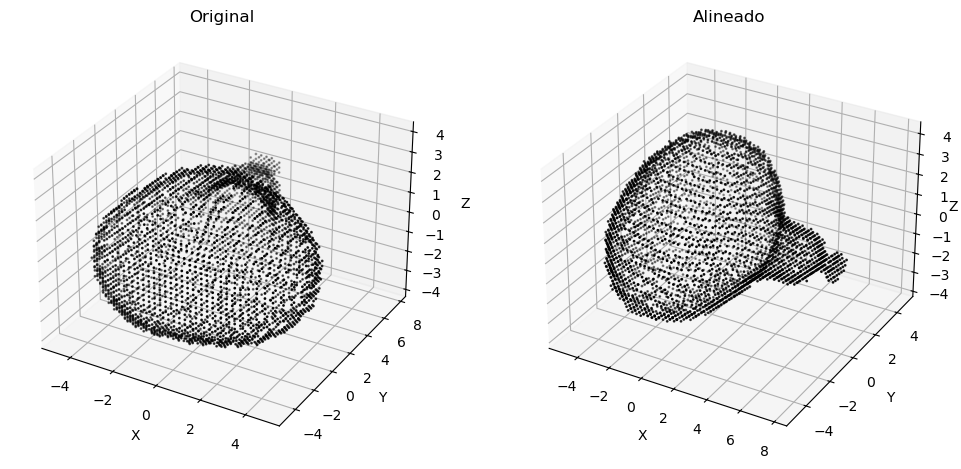

In [ ]:
# Visualización
fig = plt.figure(figsize=(12, 6))

# Original
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(points_centered[:, 0],
            points_centered[:, 1],
            points_centered[:, 2],
            s=1,
            c='black')
ax1.set_title("Original")
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Alineado
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(points_aligned[:, 0],
            points_aligned[:, 1],
            points_aligned[:, 2],
            s=1,
            c='black')
ax2.set_title("Alineado")
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.zaxis.labelpad = -5
plt.show()

In [ ]:
import numpy as np
import trimesh
from collections import deque
from scipy.ndimage import binary_dilation, binary_closing


# Relleno 3D
def fill_interior(volume):

    visited = np.zeros_like(volume, dtype=bool)
    queue = deque()

    nx, ny, nz = volume.shape

    # Inicializar con bordes en exterior
    for x in [0, nx-1]:
        for y in range(ny):
            for z in range(nz):
                if volume[x,y,z] == 0:
                    queue.append((x,y,z))
                    visited[x,y,z] = True

    for y in [0, ny-1]:
        for x in range(nx):
            for z in range(nz):
                if volume[x,y,z] == 0 and not visited[x,y,z]:
                    queue.append((x,y,z))
                    visited[x,y,z] = True

    for z in [0, nz-1]:
        for x in range(nx):
            for y in range(ny):
                if volume[x,y,z] == 0 and not visited[x,y,z]:
                    queue.append((x,y,z))
                    visited[x,y,z] = True

    # BFS exterior
    directions = [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]

    while queue:
        x,y,z = queue.popleft()

        for dx,dy,dz in directions:
            nx_, ny_, nz_ = x+dx, y+dy, z+dz

            if (0 <= nx_ < nx and 0 <= ny_ < ny and 0 <= nz_ < nz):
                if volume[nx_,ny_,nz_] == 0 and not visited[nx_,ny_,nz_]:
                    visited[nx_,ny_,nz_] = True
                    queue.append((nx_,ny_,nz_))

    # En lo no visitado, interior se rellena
    volume_filled = volume.copy()
    volume_filled[(volume == 0) & (~visited)] = 1

    return volume_filled

# Tranformar el voxel a mesh
def voxel_to_mesh(volume):

    vertices = []
    faces = []
    vdict = {}

    def add_face(quad):
        idxs = []
        for v in quad:
            if v not in vdict:
                vdict[v] = len(vertices)
                vertices.append(v)
            idxs.append(vdict[v])

        faces.append((idxs[0], idxs[1], idxs[2]))
        faces.append((idxs[0], idxs[2], idxs[3]))

    dirs = [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]

    nx, ny, nz = volume.shape

    def get_voxel(x,y,z):
        if 0 <= x < nx and 0 <= y < ny and 0 <= z < nz:
            return volume[x,y,z]
        return 0

    for x in range(nx):
        for y in range(ny):
            for z in range(nz):

                if volume[x,y,z] == 0:
                    continue

                for dx,dy,dz in dirs:
                    if get_voxel(x+dx,y+dy,z+dz) == 1:
                        continue

                    if (dx,dy,dz)==(1,0,0):
                        quad=[(x+1,y,z),(x+1,y+1,z),(x+1,y+1,z+1),(x+1,y,z+1)]
                    elif (dx,dy,dz)==(-1,0,0):
                        quad=[(x,y,z),(x,y,z+1),(x,y+1,z+1),(x,y+1,z)]
                    elif (dx,dy,dz)==(0,1,0):
                        quad=[(x,y+1,z),(x,y+1,z+1),(x+1,y+1,z+1),(x+1,y+1,z)]
                    elif (dx,dy,dz)==(0,-1,0):
                        quad=[(x,y,z),(x+1,y,z),(x+1,y,z+1),(x,y,z+1)]
                    elif (dx,dy,dz)==(0,0,1):
                        quad=[(x,y,z+1),(x+1,y,z+1),(x+1,y+1,z+1),(x,y+1,z+1)]
                    elif (dx,dy,dz)==(0,0,-1):
                        quad=[(x,y,z),(x,y+1,z),(x+1,y+1,z),(x+1,y,z)]

                    add_face(quad)

    return np.array(vertices), np.array(faces)

def fill_volume_scanlines(volume):
    vol = volume.copy()
    nx, ny, nz = vol.shape

    # Rellenar en X
    for y in range(ny):
        for z in range(nz):
            xs = np.where(vol[:, y, z] == 1)[0]
            if len(xs) > 1:
                vol[xs.min():xs.max()+1, y, z] = 1

    # Rellenar en Y
    for x in range(nx):
        for z in range(nz):
            ys = np.where(vol[x, :, z] == 1)[0]
            if len(ys) > 1:
                vol[x, ys.min():ys.max()+1, z] = 1

    # Rellenar en Z
    for x in range(nx):
        for y in range(ny):
            zs = np.where(vol[x, y, :] == 1)[0]
            if len(zs) > 1:
                vol[x, y, zs.min():zs.max()+1] = 1

    return vol

# Construir voxel mesh
def build_voxel_mesh(points, voxel_size, name):

    grid = np.floor(points / voxel_size).astype(int)
    grid -= grid.min(axis=0)

    shape = grid.max(axis=0) + 3
    volume = np.zeros(shape, dtype=np.uint8)

    volume[grid[:,0], grid[:,1], grid[:,2]] = 1

    # Primero la dilatación leve para evitar hoyos
    volume = binary_dilation(volume, iterations=1)

    # Suavizar las conexiones
    volume = binary_closing(volume, iterations=1)
    volume = fill_interior(volume)
    # Mesh
    verts, faces = voxel_to_mesh(volume)
    verts = verts * voxel_size

    mesh = trimesh.Trimesh(vertices=verts, faces=faces)
    mesh.vertices -= mesh.vertices.mean(axis=0)
    mesh.export(f"{name}.obj")


# Ejecutar la contrucción del voxel mesh
build_voxel_mesh(points_centered, voxel_size, f"original_voxel_{object_name}")
build_voxel_mesh(points_aligned, voxel_size, f"aligned_voxel_{object_name}")

print("Listo el voxel .obj.")

Listo el voxel .obj.
